# NLM Bottleneck Analysis — VS Code Version

This notebook profiles a complete grayscale image-denoising pipeline and verifies whether the naive CPU implementation of **Non-Local Means (NLM)** is the computational bottleneck.

## Local environment

Select the correct Python 3.12 kernel in VS Code before running the notebook.

```text
project-root/
├── data/
│   └── input/
├── notebooks/
│   └── 00_nlm_bottleneck_analysis_vscode.ipynb
├── outputs/
└── src/
    └── nlm/
        └── cpu.py
```

In [1]:
import importlib
import platform
import sys
import time
import warnings
from pathlib import Path
from typing import Callable

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from skimage import data as skimage_data
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)


def find_project_root(start: Path) -> Path:
    """Find the nearest parent that looks like the project root."""
    start = start.resolve()
    markers = (
        ".git",
        "pyproject.toml",
        "requirements.txt",
        "src",
    )

    for candidate in (start, *start.parents):
        if any((candidate / marker).exists() for marker in markers):
            return candidate

    return start


PROJECT_ROOT = find_project_root(Path.cwd())
INPUT_DIR = PROJECT_ROOT / "data" / "input"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "nlm_bottleneck_analysis"

INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Environment")
print("-" * 60)
print(f"Python:       {platform.python_version()}")
print(f"Working dir:  {Path.cwd().resolve()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Input dir:    {INPUT_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

Environment
------------------------------------------------------------
Python:       3.12.10
Working dir:  E:\Lap trinh song song ud\gpu_dense_vector_retrieval\notebooks
Project root: E:\Lap trinh song song ud\gpu_dense_vector_retrieval
Input dir:    E:\Lap trinh song song ud\gpu_dense_vector_retrieval\data\input
Output dir:   E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis


## Configuration and input image

The notebook first selects the first image in `data/input/`. If the folder is empty, it creates a reproducible sample image so that **Run All** still works.

In [2]:
TARGET_SIZE = 128

PATCH_SIZE = 3
SEARCH_WINDOW_SIZE = 7
FILTER_H = 0.12

NOISE_SIGMA = 0.08
RANDOM_SEED = 42

RESIZE_MODE = "resize"
# Supported values:
# "resize"      -> resize the full image.
# "center_crop" -> crop the largest centered square, then resize.

NLM_BENCHMARK_REPEATS = 3
USE_PROJECT_CPU_IMPLEMENTATION = True
CREATE_SAMPLE_IMAGE_IF_MISSING = True

# Change this path to use a specific local image.
IMAGE_PATH = INPUT_DIR / "sample.jpg"

supported_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
}

if not IMAGE_PATH.exists():
    image_candidates = sorted(
        path
        for path in INPUT_DIR.iterdir()
        if path.is_file()
        and path.suffix.lower() in supported_extensions
    )

    if image_candidates:
        IMAGE_PATH = image_candidates[0]
        print(
            "Configured image was not found. "
            f"Using: {IMAGE_PATH.name}"
        )
    elif CREATE_SAMPLE_IMAGE_IF_MISSING:
        sample_image = skimage_data.camera()
        saved = cv2.imwrite(
            str(IMAGE_PATH),
            sample_image,
        )
        if not saved:
            raise IOError(
                f"Could not create sample image at {IMAGE_PATH}"
            )
        print(
            "No local input image was found. "
            f"Created reproducible sample: {IMAGE_PATH}"
        )
    else:
        raise FileNotFoundError(
            "No input image was found. Place an image in "
            f"{INPUT_DIR} or update IMAGE_PATH."
        )

if PATCH_SIZE % 2 == 0:
    raise ValueError("PATCH_SIZE must be odd.")

if SEARCH_WINDOW_SIZE % 2 == 0:
    raise ValueError("SEARCH_WINDOW_SIZE must be odd.")

if SEARCH_WINDOW_SIZE < PATCH_SIZE:
    raise ValueError(
        "SEARCH_WINDOW_SIZE must be greater than or equal "
        "to PATCH_SIZE."
    )

if FILTER_H <= 0:
    raise ValueError("FILTER_H must be positive.")

if NLM_BENCHMARK_REPEATS < 1:
    raise ValueError("NLM_BENCHMARK_REPEATS must be at least 1.")

print()
print("Configuration")
print("-" * 60)
print(f"Image path:          {IMAGE_PATH}")
print(f"Target size:         {TARGET_SIZE} x {TARGET_SIZE}")
print(f"Patch size:          {PATCH_SIZE} x {PATCH_SIZE}")
print(
    "Search window size:  "
    f"{SEARCH_WINDOW_SIZE} x {SEARCH_WINDOW_SIZE}"
)
print(f"Filtering h:         {FILTER_H}")
print(f"Noise sigma:         {NOISE_SIGMA}")
print(f"Resize mode:         {RESIZE_MODE}")
print(f"Benchmark repeats:   {NLM_BENCHMARK_REPEATS}")

No local input image was found. Created reproducible sample: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\data\input\sample.jpg

Configuration
------------------------------------------------------------
Image path:          E:\Lap trinh song song ud\gpu_dense_vector_retrieval\data\input\sample.jpg
Target size:         128 x 128
Patch size:          3 x 3
Search window size:  7 x 7
Filtering h:         0.12
Noise sigma:         0.08
Resize mode:         resize
Benchmark repeats:   3


## Image preprocessing

In [3]:
def resize_or_center_crop(
    image_rgb: np.ndarray,
    target_size: int,
    mode: str = "resize",
) -> np.ndarray:
    """Resize the full image or center-crop before resizing."""

    if target_size <= 0:
        raise ValueError("target_size must be positive.")

    if mode == "resize":
        return cv2.resize(
            image_rgb,
            (target_size, target_size),
            interpolation=cv2.INTER_AREA,
        )

    if mode == "center_crop":
        height, width = image_rgb.shape[:2]
        crop_size = min(height, width)

        start_y = (height - crop_size) // 2
        start_x = (width - crop_size) // 2

        cropped = image_rgb[
            start_y:start_y + crop_size,
            start_x:start_x + crop_size,
        ]

        return cv2.resize(
            cropped,
            (target_size, target_size),
            interpolation=cv2.INTER_AREA,
        )

    raise ValueError(
        "mode must be either 'resize' or 'center_crop'."
    )

## CPU NLM implementation

The notebook first tries to import the implementation from the project:

```python
from src.nlm.cpu import nlm_cpu_naive
```

It also supports the common `src`-layout import `from nlm.cpu import nlm_cpu_naive`. A local fallback is retained only to keep this analysis notebook independently executable.

In [4]:
def nlm_cpu_naive_fallback(
    image: np.ndarray,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
) -> np.ndarray:
    """Standalone grayscale CPU implementation of naive NLM."""

    if image.ndim != 2:
        raise ValueError(
            "The CPU NLM implementation expects a 2D grayscale image."
        )

    if patch_size % 2 == 0:
        raise ValueError("patch_size must be odd.")

    if search_window_size % 2 == 0:
        raise ValueError("search_window_size must be odd.")

    if search_window_size < patch_size:
        raise ValueError(
            "search_window_size must be greater than or equal "
            "to patch_size."
        )

    if h <= 0:
        raise ValueError("h must be positive.")

    image = np.asarray(image, dtype=np.float32)
    height, width = image.shape

    patch_radius = patch_size // 2
    search_radius = search_window_size // 2
    padding_radius = patch_radius + search_radius

    padded = np.pad(
        image,
        pad_width=padding_radius,
        mode="reflect",
    )

    output = np.zeros_like(image, dtype=np.float32)
    h_squared = np.float32(h * h)

    for output_y in range(height):
        for output_x in range(width):
            center_y = output_y + padding_radius
            center_x = output_x + padding_radius

            reference_patch = padded[
                center_y - patch_radius:
                center_y + patch_radius + 1,
                center_x - patch_radius:
                center_x + patch_radius + 1,
            ]

            weighted_sum = 0.0
            total_weight = 0.0

            for offset_y in range(
                -search_radius,
                search_radius + 1,
            ):
                for offset_x in range(
                    -search_radius,
                    search_radius + 1,
                ):
                    candidate_y = center_y + offset_y
                    candidate_x = center_x + offset_x

                    candidate_patch = padded[
                        candidate_y - patch_radius:
                        candidate_y + patch_radius + 1,
                        candidate_x - patch_radius:
                        candidate_x + patch_radius + 1,
                    ]

                    difference = (
                        reference_patch - candidate_patch
                    )

                    patch_distance = np.mean(
                        difference * difference
                    )

                    weight = np.exp(
                        -patch_distance / h_squared
                    )

                    candidate_center_pixel = padded[
                        candidate_y,
                        candidate_x,
                    ]

                    weighted_sum += (
                        weight * candidate_center_pixel
                    )
                    total_weight += weight

            output[output_y, output_x] = (
                weighted_sum / total_weight
            )

    return np.clip(
        output,
        0.0,
        1.0,
    ).astype(np.float32, copy=False)


def resolve_cpu_nlm_implementation():
    """Prefer the modular project implementation when available."""

    if USE_PROJECT_CPU_IMPLEMENTATION:
        import_errors = []

        for module_name in (
            "src.nlm.cpu",
            "nlm.cpu",
        ):
            try:
                module = importlib.import_module(module_name)
                implementation = getattr(
                    module,
                    "nlm_cpu_naive",
                )
                return implementation, module_name
            except (
                ImportError,
                AttributeError,
            ) as exc:
                import_errors.append(
                    f"{module_name}: {exc}"
                )

        warnings.warn(
            "Could not import the modular CPU implementation. "
            "Using the notebook fallback.\n"
            + "\n".join(import_errors),
            RuntimeWarning,
        )

    return (
        nlm_cpu_naive_fallback,
        "notebook fallback",
    )


nlm_cpu_naive, NLM_IMPLEMENTATION_SOURCE = (
    resolve_cpu_nlm_implementation()
)

print(
    "CPU NLM implementation source: "
    f"{NLM_IMPLEMENTATION_SOURCE}"
)

CPU NLM implementation source: src.nlm.cpu


## Complete profiled pipeline

The end-to-end pipeline is measured once per stage. The synthetic-noise generation and PSNR/SSIM evaluation stages are marked as experiment-only stages and excluded from the practical denoising-flow total.

In [5]:
def run_full_image_pipeline(
    image_path: str | Path,
    denoise_fn: Callable[..., np.ndarray],
    target_size: int = 128,
    resize_mode: str = "resize",
    noise_sigma: float = 0.08,
    patch_size: int = 3,
    search_window_size: int = 7,
    h: float = 0.12,
    random_seed: int = 42,
    output_directory: str | Path = "nlm_pipeline_outputs",
) -> dict:
    """Run and profile the complete CPU NLM experiment."""

    image_path = Path(image_path).expanduser().resolve()
    output_path = Path(output_directory).expanduser().resolve()
    output_path.mkdir(parents=True, exist_ok=True)

    if not image_path.is_file():
        raise FileNotFoundError(
            f"Input image does not exist: {image_path}"
        )

    timings: dict[str, float] = {}

    start = time.perf_counter()
    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR,
    )
    timings["1. Image read and decode"] = (
        time.perf_counter() - start
    )

    if image_bgr is None:
        raise ValueError(
            f"OpenCV could not decode image: {image_path}"
        )

    start = time.perf_counter()
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )
    timings["2. BGR to RGB"] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()
    resized_rgb = resize_or_center_crop(
        image_rgb,
        target_size=target_size,
        mode=resize_mode,
    )
    timings["3. Resize or crop"] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()
    grayscale_uint8 = cv2.cvtColor(
        resized_rgb,
        cv2.COLOR_RGB2GRAY,
    )
    timings["4. RGB to grayscale"] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()
    clean_float = (
        grayscale_uint8.astype(np.float32)
        / np.float32(255.0)
    )
    timings["5. Float32 normalization"] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()
    rng = np.random.default_rng(random_seed)
    noise = rng.normal(
        loc=0.0,
        scale=noise_sigma,
        size=clean_float.shape,
    ).astype(np.float32)

    noisy_float = np.clip(
        clean_float + noise,
        0.0,
        1.0,
    ).astype(np.float32)
    timings["6. Gaussian-noise generation"] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()
    denoised_float = denoise_fn(
        noisy_float,
        patch_size=patch_size,
        search_window_size=search_window_size,
        h=h,
    )
    timings["7. CPU NLM denoising"] = (
        time.perf_counter() - start
    )

    denoised_float = np.asarray(
        denoised_float,
        dtype=np.float32,
    )

    if denoised_float.shape != noisy_float.shape:
        raise ValueError(
            "The NLM output shape does not match the input shape: "
            f"{denoised_float.shape} != {noisy_float.shape}"
        )

    if not np.all(np.isfinite(denoised_float)):
        raise ValueError(
            "The NLM output contains NaN or infinite values."
        )

    denoised_float = np.clip(
        denoised_float,
        0.0,
        1.0,
    )

    start = time.perf_counter()
    noisy_psnr = peak_signal_noise_ratio(
        clean_float,
        noisy_float,
        data_range=1.0,
    )
    denoised_psnr = peak_signal_noise_ratio(
        clean_float,
        denoised_float,
        data_range=1.0,
    )
    noisy_ssim = structural_similarity(
        clean_float,
        noisy_float,
        data_range=1.0,
    )
    denoised_ssim = structural_similarity(
        clean_float,
        denoised_float,
        data_range=1.0,
    )
    timings["8. PSNR and SSIM evaluation"] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()
    noisy_uint8 = np.rint(
        np.clip(noisy_float, 0.0, 1.0)
        * 255.0
    ).astype(np.uint8)
    denoised_uint8 = np.rint(
        np.clip(denoised_float, 0.0, 1.0)
        * 255.0
    ).astype(np.uint8)
    timings["9. Float32 to uint8"] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()
    clean_output_file = (
        output_path / "clean_grayscale.png"
    )
    noisy_output_file = (
        output_path / "noisy_grayscale.png"
    )
    denoised_output_file = (
        output_path / "denoised_nlm_cpu.png"
    )

    save_status = (
        cv2.imwrite(
            str(clean_output_file),
            grayscale_uint8,
        ),
        cv2.imwrite(
            str(noisy_output_file),
            noisy_uint8,
        ),
        cv2.imwrite(
            str(denoised_output_file),
            denoised_uint8,
        ),
    )
    timings["10. PNG encoding and saving"] = (
        time.perf_counter() - start
    )

    if not all(save_status):
        raise IOError(
            "One or more output images could not be saved."
        )

    experimental_total = sum(timings.values())

    denoising_stage_names = {
        "1. Image read and decode",
        "2. BGR to RGB",
        "3. Resize or crop",
        "4. RGB to grayscale",
        "5. Float32 normalization",
        "7. CPU NLM denoising",
        "9. Float32 to uint8",
        "10. PNG encoding and saving",
    }

    denoising_flow_total = sum(
        runtime
        for stage_name, runtime in timings.items()
        if stage_name in denoising_stage_names
    )

    rows = []
    for stage_name, runtime in timings.items():
        included = stage_name in denoising_stage_names
        rows.append(
            {
                "Stage": stage_name,
                "Runtime (s)": runtime,
                "Experimental flow (%)": (
                    runtime
                    / experimental_total
                    * 100.0
                ),
                "Included in denoising flow": included,
                "Denoising flow (%)": (
                    runtime
                    / denoising_flow_total
                    * 100.0
                    if included
                    else np.nan
                ),
            }
        )

    runtime_table = pd.DataFrame(rows)
    max_runtime = runtime_table["Runtime (s)"].max()
    runtime_table["Is bottleneck"] = np.isclose(
        runtime_table["Runtime (s)"],
        max_runtime,
    )

    nlm_runtime = timings[
        "7. CPU NLM denoising"
    ]

    runtime_csv = (
        output_path / "runtime_breakdown.csv"
    )
    runtime_table.to_csv(
        runtime_csv,
        index=False,
    )

    return {
        "input_image_path": str(image_path),
        "original_rgb": image_rgb,
        "resized_rgb": resized_rgb,
        "clean_float": clean_float,
        "noisy_float": noisy_float,
        "denoised_float": denoised_float,
        "runtime_table": runtime_table,
        "timings": timings,
        "experimental_total": experimental_total,
        "denoising_flow_total": denoising_flow_total,
        "nlm_experimental_percentage": (
            nlm_runtime
            / experimental_total
            * 100.0
        ),
        "nlm_denoising_flow_percentage": (
            nlm_runtime
            / denoising_flow_total
            * 100.0
        ),
        "noisy_psnr": noisy_psnr,
        "denoised_psnr": denoised_psnr,
        "noisy_ssim": noisy_ssim,
        "denoised_ssim": denoised_ssim,
        "output_files": {
            "clean": str(clean_output_file),
            "noisy": str(noisy_output_file),
            "denoised": str(denoised_output_file),
            "runtime_csv": str(runtime_csv),
        },
    }

In [6]:
pipeline_result = run_full_image_pipeline(
    image_path=IMAGE_PATH,
    denoise_fn=nlm_cpu_naive,
    target_size=TARGET_SIZE,
    resize_mode=RESIZE_MODE,
    noise_sigma=NOISE_SIGMA,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
    random_seed=RANDOM_SEED,
    output_directory=OUTPUT_DIR,
)

## Runtime table and automatic bottleneck detection

In [7]:
runtime_table = pipeline_result[
    "runtime_table"
].copy()

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.6f}",
)

display(runtime_table)

bottleneck_row = runtime_table.loc[
    runtime_table["Runtime (s)"].idxmax()
]

print()
print(
    "Detected bottleneck: "
    f"{bottleneck_row['Stage']} "
    f"({bottleneck_row['Runtime (s)']:.6f} s)"
)

,Stage,Runtime (s),Experimental flow (%),Included in denoising flow,Denoising flow (%),Is bottleneck
0,1. Image read and decode,0.014723,0.201141,True,0.201209,False
1,2. BGR to RGB,0.006417,0.087666,True,0.087696,False
2,3. Resize or crop,0.001685,0.023019,True,0.023027,False
3,4. RGB to grayscale,0.000907,0.012393,True,0.012397,False
4,5. Float32 normalization,0.000106,0.001444,True,0.001445,False
5,6. Gaussian-noise generation,0.000480,0.006555,False,NaN,False
6,7. CPU NLM denoising,7.275575,99.397188,True,99.431116,True
7,8. PSNR and SSIM evaluation,0.002018,0.027567,False,NaN,False
8,9. Float32 to uint8,0.000063,0.000863,True,0.000864,False
9,10. PNG encoding and saving,0.017726,0.242164,True,0.242247,False



Detected bottleneck: 7. CPU NLM denoising (7.275575 s)


In [8]:
print("Runtime summary")
print("-" * 60)
print(
    "Complete experimental flow: "
    f"{pipeline_result['experimental_total']:.6f} s"
)
print(
    "Actual denoising flow:       "
    f"{pipeline_result['denoising_flow_total']:.6f} s"
)
print(
    "NLM share of experimental flow: "
    f"{pipeline_result['nlm_experimental_percentage']:.2f}%"
)
print(
    "NLM share of denoising flow:    "
    f"{pipeline_result['nlm_denoising_flow_percentage']:.2f}%"
)

print()
print("Quality summary")
print("-" * 60)
print(
    f"Noisy PSNR:       "
    f"{pipeline_result['noisy_psnr']:.2f} dB"
)
print(
    f"Denoised PSNR:    "
    f"{pipeline_result['denoised_psnr']:.2f} dB"
)
print(
    f"PSNR improvement: "
    f"{pipeline_result['denoised_psnr'] - pipeline_result['noisy_psnr']:.2f} dB"
)
print(
    f"Noisy SSIM:       "
    f"{pipeline_result['noisy_ssim']:.4f}"
)
print(
    f"Denoised SSIM:    "
    f"{pipeline_result['denoised_ssim']:.4f}"
)

Runtime summary
------------------------------------------------------------
Complete experimental flow: 7.319699 s
Actual denoising flow:       7.317202 s
NLM share of experimental flow: 99.40%
NLM share of denoising flow:    99.43%

Quality summary
------------------------------------------------------------
Noisy PSNR:       22.20 dB
Denoised PSNR:    29.65 dB
PSNR improvement: 7.44 dB
Noisy SSIM:       0.4301
Denoised SSIM:    0.8081


## Repeated CPU NLM benchmark

The previous table profiles one full pipeline execution. The following benchmark measures only the NLM operation several times and reports the median, which is less sensitive to occasional timing noise.

In [9]:
def benchmark_cpu_nlm(
    denoise_fn: Callable[..., np.ndarray],
    image: np.ndarray,
    repeats: int,
    patch_size: int,
    search_window_size: int,
    h: float,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Measure repeated CPU NLM executions with perf_counter."""

    runtimes = []
    latest_output = None

    for run_index in range(1, repeats + 1):
        start = time.perf_counter()
        latest_output = denoise_fn(
            image,
            patch_size=patch_size,
            search_window_size=search_window_size,
            h=h,
        )
        elapsed = time.perf_counter() - start

        runtimes.append(
            {
                "Run": run_index,
                "Runtime (s)": elapsed,
            }
        )

    return pd.DataFrame(runtimes), latest_output


nlm_benchmark_table, benchmark_output = benchmark_cpu_nlm(
    denoise_fn=nlm_cpu_naive,
    image=pipeline_result["noisy_float"],
    repeats=NLM_BENCHMARK_REPEATS,
    patch_size=PATCH_SIZE,
    search_window_size=SEARCH_WINDOW_SIZE,
    h=FILTER_H,
)

benchmark_output = np.asarray(
    benchmark_output,
    dtype=np.float32,
)

if not np.allclose(
    benchmark_output,
    pipeline_result["denoised_float"],
    atol=1e-6,
    rtol=1e-5,
):
    raise AssertionError(
        "Repeated benchmark output differs from the pipeline output."
    )

median_nlm_runtime = float(
    nlm_benchmark_table["Runtime (s)"].median()
)

benchmark_csv = (
    OUTPUT_DIR / "cpu_nlm_repeated_benchmark.csv"
)
nlm_benchmark_table.to_csv(
    benchmark_csv,
    index=False,
)

display(nlm_benchmark_table)

print(
    f"Median CPU NLM runtime "
    f"({NLM_BENCHMARK_REPEATS} runs): "
    f"{median_nlm_runtime:.6f} s"
)
print(
    f"Minimum runtime: "
    f"{nlm_benchmark_table['Runtime (s)'].min():.6f} s"
)
print(
    f"Maximum runtime: "
    f"{nlm_benchmark_table['Runtime (s)'].max():.6f} s"
)

,Run,Runtime (s)
0,1,7.268900
1,2,7.220708
2,3,7.157073


Median CPU NLM runtime (3 runs): 7.220708 s
Minimum runtime: 7.157073 s
Maximum runtime: 7.268900 s


## Runtime visualizations

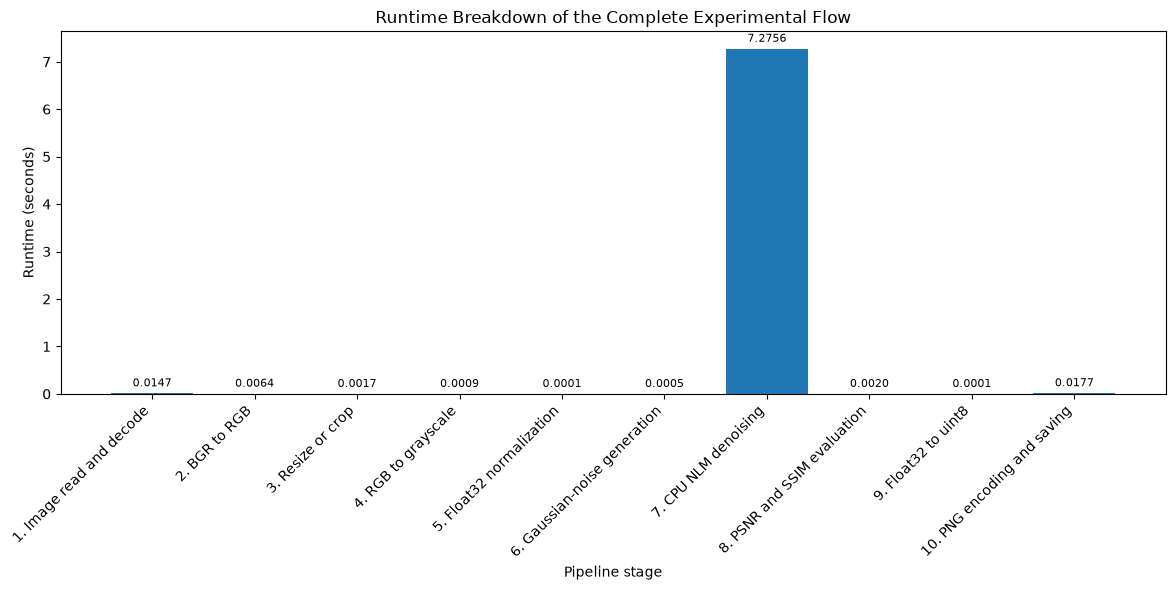

In [10]:
experimental_profile = runtime_table.copy()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    experimental_profile["Stage"],
    experimental_profile["Runtime (s)"],
)

ax.set_xlabel("Pipeline stage")
ax.set_ylabel("Runtime (seconds)")
ax.set_title(
    "Runtime Breakdown of the Complete Experimental Flow"
)
ax.tick_params(
    axis="x",
    rotation=45,
)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.bar_label(
    bars,
    fmt="%.4f",
    padding=3,
    fontsize=8,
)

fig.tight_layout()
runtime_figure = (
    OUTPUT_DIR / "runtime_breakdown_seconds.png"
)
fig.savefig(
    runtime_figure,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

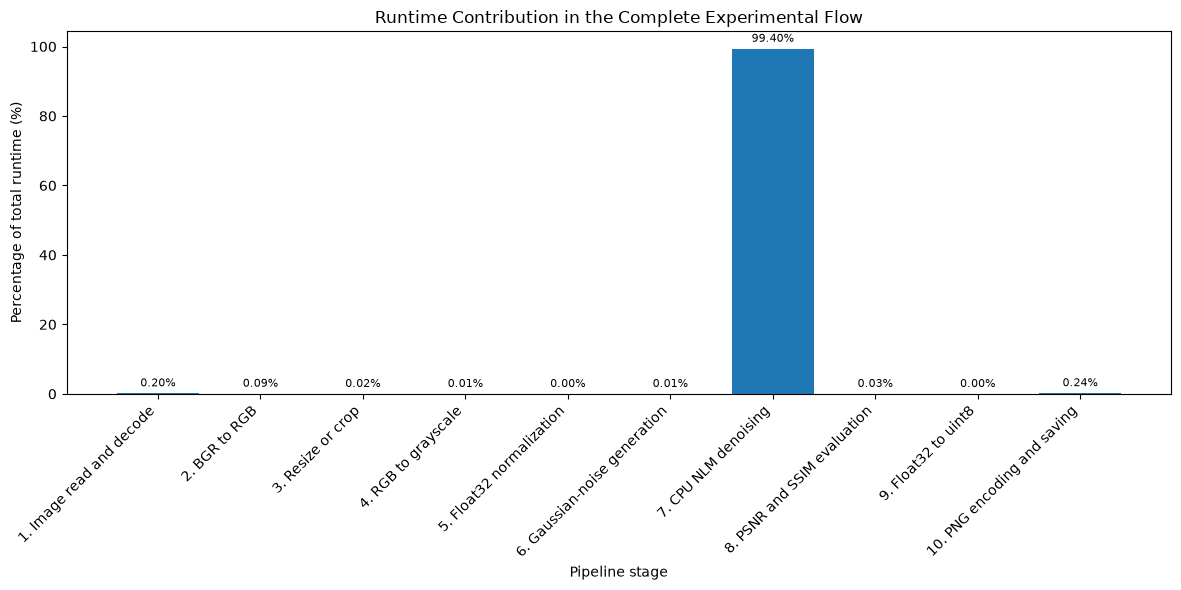

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    experimental_profile["Stage"],
    experimental_profile[
        "Experimental flow (%)"
    ],
)

ax.set_xlabel("Pipeline stage")
ax.set_ylabel("Percentage of total runtime (%)")
ax.set_title(
    "Runtime Contribution in the Complete Experimental Flow"
)
ax.tick_params(
    axis="x",
    rotation=45,
)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.bar_label(
    bars,
    fmt="%.2f%%",
    padding=3,
    fontsize=8,
)

fig.tight_layout()
experimental_percentage_figure = (
    OUTPUT_DIR / "experimental_runtime_percentage.png"
)
fig.savefig(
    experimental_percentage_figure,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

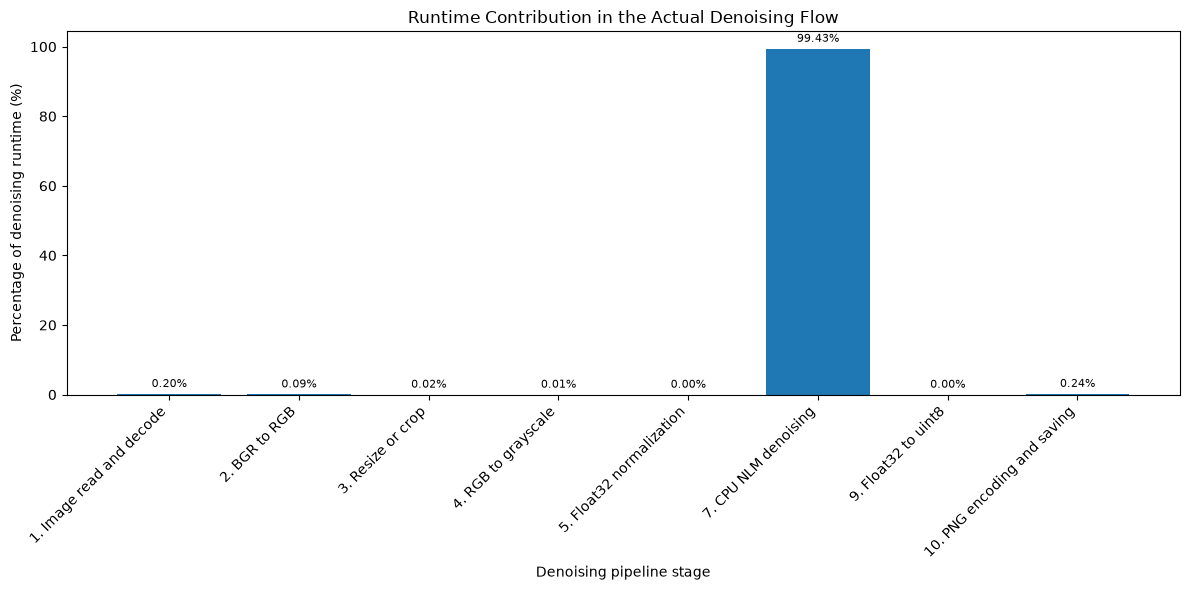

In [12]:
denoising_profile = runtime_table[
    runtime_table[
        "Included in denoising flow"
    ]
].copy()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    denoising_profile["Stage"],
    denoising_profile[
        "Denoising flow (%)"
    ],
)

ax.set_xlabel("Denoising pipeline stage")
ax.set_ylabel("Percentage of denoising runtime (%)")
ax.set_title(
    "Runtime Contribution in the Actual Denoising Flow"
)
ax.tick_params(
    axis="x",
    rotation=45,
)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.bar_label(
    bars,
    fmt="%.2f%%",
    padding=3,
    fontsize=8,
)

fig.tight_layout()
denoising_percentage_figure = (
    OUTPUT_DIR / "denoising_runtime_percentage.png"
)
fig.savefig(
    denoising_percentage_figure,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## Image-quality comparison

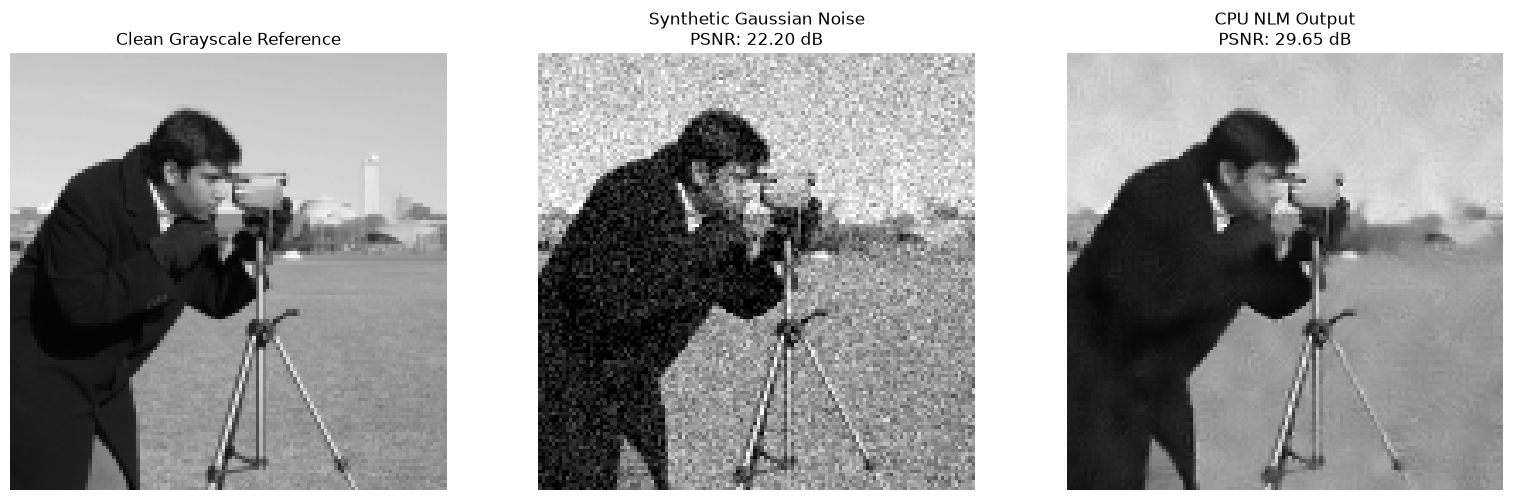

In [13]:
clean_image = pipeline_result["clean_float"]
noisy_image = pipeline_result["noisy_float"]
denoised_image = pipeline_result[
    "denoised_float"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

axes[0].imshow(
    clean_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title("Clean Grayscale Reference")
axes[0].axis("off")

axes[1].imshow(
    noisy_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[1].set_title(
    "Synthetic Gaussian Noise\n"
    f"PSNR: {pipeline_result['noisy_psnr']:.2f} dB"
)
axes[1].axis("off")

axes[2].imshow(
    denoised_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[2].set_title(
    "CPU NLM Output\n"
    f"PSNR: {pipeline_result['denoised_psnr']:.2f} dB"
)
axes[2].axis("off")

fig.tight_layout()
comparison_figure = (
    OUTPUT_DIR / "image_quality_comparison.png"
)
fig.savefig(
    comparison_figure,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## Final interpretation

For an image of size \(H \times W\), a search window of size \(S \times S\), and a patch of size \(P \times P\), the naive CPU implementation performs approximately:

\[
O(HW S^2 P^2)
\]

operations. Each output pixel can be processed independently after the required image region is available, which makes NLM a strong candidate for CUDA parallelization. The next implementations can therefore map one output pixel to one GPU thread, followed by shared-memory tiling to reduce repeated global-memory access.

In [14]:
print("Saved outputs")
print("-" * 60)

saved_outputs = {
    **pipeline_result["output_files"],
    "repeated_benchmark_csv": str(benchmark_csv),
    "runtime_figure": str(runtime_figure),
    "experimental_percentage_figure": str(
        experimental_percentage_figure
    ),
    "denoising_percentage_figure": str(
        denoising_percentage_figure
    ),
    "comparison_figure": str(comparison_figure),
}

for name, file_path in saved_outputs.items():
    print(f"{name}: {file_path}")

Saved outputs
------------------------------------------------------------
clean: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis\clean_grayscale.png
noisy: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis\noisy_grayscale.png
denoised: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis\denoised_nlm_cpu.png
runtime_csv: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis\runtime_breakdown.csv
repeated_benchmark_csv: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis\cpu_nlm_repeated_benchmark.csv
runtime_figure: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis\runtime_breakdown_seconds.png
experimental_percentage_figure: E:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\nlm_bottleneck_analysis\experimental_runtime_percentage.png
denoising_percentage_figure: E:\Lap trinh